```mermaid
flowchart TD
    A[FairMOT idea] --> B[Shared encoder decoder]
    B --> C[Classification\nforeground heatmap]
    B --> D[Detection\noffset plus size]
    B --> E[Re identification\n128 dimensional embedding]
    C --> F[One center per cow]
    D --> F
    E --> F
    F --> G[Per frame evaluation\nnot online tracking]
```

```mermaid
flowchart LR
    A[mmCows] --> B[One cow class]
    A --> C[16 known identities]
    B --> D[Classification and detection]
    C --> E[Closed set re identification]
    D --> F[Three named heads]
    E --> F
```

```mermaid
flowchart TD
    A[Anchor based boxes] --> B[Overlapping or ambiguous identity features]
    C[Anchor free center] --> D[One feature per object]
    D --> E[Cleaner joint detection plus re identification]
```


```mermaid
flowchart LR
    A[mmCows visual frames] --> B[Four cameras]
    B --> C[YOLO labels: identity center width height]
    C --> D[Stride sampling]
    D --> E[Drop empty frames]
    E --> F[Resize 4480 by 2800 to 640 by 400]
    F --> G[Train and validation pools]
```

```mermaid
flowchart TD
    A[Identity ids 1 to 16] --> B[Training class ids 0 to 15]
    A --> C[Same identities may appear in validation]
    C --> D[Validation is never used for weight updates]
```


In [1]:
import csv
import math
import random
from pathlib import Path

import torch
from torch import nn
import torch.nn.functional as F
from PIL import Image, ImageFile
from torch.utils.data import DataLoader, Dataset

ImageFile.LOAD_TRUNCATED_IMAGES = True  # a few mmCows jpgs are partially written; don't crash on them

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

torch.manual_seed(0)
random.seed(0)

# This notebook is intentionally scoped to the identity-labelled mmCows benchmark.

# four cameras for different angles images 
# image names are same under different cameras

DATASET_NAME = "mmCows"
DATA_ROOT = Path("benchmarks/mmCows/visual_data/visual_data")
IMAGE_ROOT = DATA_ROOT / "images" / "0725"
LABEL_ROOT = DATA_ROOT / "labels" / "combined" / "0725"
CAMERAS = ("cam_1", "cam_2", "cam_3", "cam_4") 

N_CLASSES = 1          # mmCows has exactly one object category ("cow")
N_IDENTITIES = 16       # cows C01..C16 -> label ids 1..16 in the .txt files
FRAME_STRIDE = 3        # keep every 3rd frame per camera to limit notebook runtime
MAX_SAMPLES = 500       # cap the combined train+validation frames; use None for the full set
IMG_W, IMG_H = 640, 400  # multiple of 4, same 8:5 aspect ratio as native frames
STRIDE = 4               # output feature map is stride 4, as in FairMOT/CenterNet
FEAT_W, FEAT_H = IMG_W // STRIDE, IMG_H // STRIDE

assert DATA_ROOT.exists(), f"Missing {DATASET_NAME} dataset: {DATA_ROOT}"
assert all((IMAGE_ROOT / camera).exists() and (LABEL_ROOT / camera).exists() for camera in CAMERAS), \
    f"Expected image and combined-label folders for all cameras under {DATA_ROOT}"

print(f"{DATASET_NAME}: cameras={', '.join(CAMERAS)}")
print(DEVICE)


mmCows: cameras=cam_1, cam_2, cam_3, cam_4
cuda


In [2]:
def parse_yolo_txt(path):
    """Read one 'id cx cy w h' label file."""
    boxes = []
    if not path.exists():
        return boxes
    for line in path.read_text().splitlines():
        parts = line.split()
        if not parts or len(parts) < 5:
            continue
        cid = int(parts[0])
        cx, cy, w, h = (float(value) for value in parts[1:5])
        if not 1 <= cid <= N_IDENTITIES:
            raise ValueError(f"Unexpected {DATASET_NAME} identity {cid} in {path}")
        boxes.append((cid, cx, cy, w, h))
    return boxes


def is_readable_image(path):
    try:
        with Image.open(path) as image:
            image.verify()
        return True
    except (OSError, ValueError):
        print(f"skipping unreadable image: {path}")
        return False


def load_frame_index():
    """Build usable (image_path, boxes) samples across all configured cameras.
    Subsampling restarts for each camera so every view contributes equally."""
    samples = []
    for camera in CAMERAS:
        image_dir = IMAGE_ROOT / camera
        label_dir = LABEL_ROOT / camera
        camera_frames = 0
        for i, txt_path in enumerate(sorted(label_dir.glob("*.txt"))):
            if i % FRAME_STRIDE != 0:
                continue
            boxes = parse_yolo_txt(txt_path)
            if not boxes:
                continue
            img_path = image_dir / (txt_path.stem + ".jpg")
            if img_path.exists() and is_readable_image(img_path):
                samples.append((img_path, boxes))
                camera_frames += 1
        print(f"{camera}: {camera_frames} usable frames")
    return samples


ALL_SAMPLES = load_frame_index()
if not ALL_SAMPLES:
    raise RuntimeError(f"No readable labelled {DATASET_NAME} frames found under {DATA_ROOT}")
random.shuffle(ALL_SAMPLES)
print(f"total samples: {len(ALL_SAMPLES)}")
print(f"out of {len(ALL_SAMPLES)} samples, {len(ALL_SAMPLES) / len(CAMERAS):.1f} per camera")
if MAX_SAMPLES is not None:
    ALL_SAMPLES = ALL_SAMPLES[:MAX_SAMPLES]
print(f"selected {len(ALL_SAMPLES)} samples for training+validation (limit={MAX_SAMPLES})")

n_val = max(1, int(0.15 * len(ALL_SAMPLES)))
if len(ALL_SAMPLES) < 2:
    raise RuntimeError("At least two readable labelled frames are required for train/validation split")
VAL_SAMPLES = ALL_SAMPLES[:n_val]
TRAIN_SAMPLES = ALL_SAMPLES[n_val:]
if not TRAIN_SAMPLES or not VAL_SAMPLES:
    raise RuntimeError("Train and validation splits must both contain at least one frame")

n_boxes_total = sum(len(b) for _, b in ALL_SAMPLES)
limit_text = "all" if MAX_SAMPLES is None else str(MAX_SAMPLES)
print(f"frames: {len(ALL_SAMPLES)} loaded (limit={limit_text}) -> {len(TRAIN_SAMPLES)} train / {len(VAL_SAMPLES)} val")
print(f"boxes:  {n_boxes_total} total, {n_boxes_total / len(ALL_SAMPLES):.1f} per frame")


cam_1: 1589 usable frames
cam_2: 1588 usable frames
cam_3: 1589 usable frames
cam_4: 1589 usable frames
total samples: 6355
out of 6355 samples, 1588.8 per camera
selected 500 samples for training+validation (limit=500)
frames: 500 loaded (limit=500) -> 425 train / 75 val
boxes:  5652 total, 11.3 per frame


In [3]:
def gaussian_radius(box_h, box_w, min_overlap=0.7):
    """How wide a Gaussian bump around an object center still guarantees an IoU >= min_overlap
    with the true box, for *some* placement of a same-size predicted box.

    Standard CornerNet (Law & Deng 2018) radius formula, which FairMOT explicitly reuses for its
    heatmap target (Sec. 4.2.1 references CornerNet/CenterNet for the detection branch). It solves
    three quadratics for the three ways a predicted box of the same size can overlap the GT box
    (fully inside, fully outside, or straddling a corner) and takes the smallest resulting radius,
    i.e. the strictest constraint."""
    a1, b1, c1 = 1, (box_h + box_w), box_w * box_h * (1 - min_overlap) / (1 + min_overlap)
    r1 = (b1 - math.sqrt(max(b1 ** 2 - 4 * a1 * c1, 0))) / 2

    a2, b2, c2 = 4, 2 * (box_h + box_w), (1 - min_overlap) * box_w * box_h
    r2 = (b2 - math.sqrt(max(b2 ** 2 - 4 * a2 * c2, 0))) / 2

    a3, b3, c3 = 4 * min_overlap, -2 * min_overlap * (box_h + box_w), (min_overlap - 1) * box_w * box_h
    r3 = (b3 + math.sqrt(max(b3 ** 2 - 4 * a3 * c3, 0))) / 2

    return max(0.0, min(r1, r2, r3))


def draw_gaussian(heatmap, cx, cy, radius):
    """Splat exp(-(dx^2+dy^2)/(2*sigma^2)) onto heatmap around (cx, cy), clipped to the image,
    keeping the maximum where two objects' Gaussians overlap (Eq. 1's M_xy is itself a sum, but
    taking the max is the standard, numerically nicer implementation used by CenterNet/FairMOT
    code releases and gives the same effective target after the >1 values are clamped)."""
    radius = max(0, int(radius))
    sigma = max(radius / 3.0, 0.5)
    h, w = heatmap.shape
    left, right = min(cx, radius), min(w - cx, radius + 1)
    top, bottom = min(cy, radius), min(h - cy, radius + 1)
    if left + right <= 0 or top + bottom <= 0:
        return
    ys = torch.arange(-top, bottom, dtype=torch.float32).view(-1, 1)
    xs = torch.arange(-left, right, dtype=torch.float32).view(1, -1)
    gauss = torch.exp(-(xs ** 2 + ys ** 2) / (2 * sigma ** 2))
    region = heatmap[cy - top:cy + bottom, cx - left:cx + right]
    torch.max(region, gauss, out=region)


class MmCowsJointDataset(Dataset):
    """Produces one training tensor bundle per frame: the resized image, plus the dense
    supervision maps for the classification head (heatmap) and, at each GT center, the box
    (offset, size) for the detection head and the identity for the re-ID head."""

    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, boxes = self.samples[idx]
        img = Image.open(img_path).convert("RGB").resize((IMG_W, IMG_H))
        img = torch.from_numpy(
            __import__("numpy").array(img)
        ).permute(2, 0, 1).float() / 255.0
        # ImageNet normalization (matches n7/n8's convention in this repo)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = (img - mean) / std

        heatmap = torch.zeros(FEAT_H, FEAT_W)   # classification target: 1 = cow center, Eq. 1
        max_boxes = len(boxes)
        offset_gt = torch.zeros(max_boxes, 2)   # detection target
        size_gt = torch.zeros(max_boxes, 2)     # detection target
        center_int = torch.zeros(max_boxes, 2, dtype=torch.long)  # (feat_x, feat_y) per box
        identity_gt = torch.zeros(max_boxes, dtype=torch.long)     # re-ID target
        mask = torch.zeros(max_boxes, dtype=torch.bool)

        for i, (cid, cx, cy, bw, bh) in enumerate(boxes):
            # normalized -> pixel -> stride-4 feature-map coordinates (paper Sec. 4.2, before Eq.1)
            px, py = cx * IMG_W, cy * IMG_H
            pw, ph = bw * IMG_W, bh * IMG_H
            fx, fy = px / STRIDE, py / STRIDE
            fx_int, fy_int = int(fx), int(fy)
            if not (0 <= fx_int < FEAT_W and 0 <= fy_int < FEAT_H):
                continue  # center fell outside the feature map after resize/rounding; drop it

            radius = gaussian_radius(ph / STRIDE, pw / STRIDE)
            draw_gaussian(heatmap, fx_int, fy_int, radius)

            offset_gt[i] = torch.tensor([fx - fx_int, fy - fy_int])       # sub-pixel offset, Eq.2
            size_gt[i] = torch.tensor([pw / STRIDE, ph / STRIDE])         # box size in feature units
            center_int[i] = torch.tensor([fx_int, fy_int])
            identity_gt[i] = cid - 1        # ids in files are 1..16 -> 0..15 for CrossEntropyLoss
            mask[i] = True

        return img, heatmap, offset_gt, size_gt, center_int, identity_gt, mask


def collate_joint(batch):
    """Frames have a variable number of boxes, so pad the per-box tensors to the batch max
    (same pattern n6/n7 use for variable-length YOLO targets) and carry a boolean mask."""
    imgs, heatmaps, offsets, sizes, centers, ids, masks = zip(*batch)
    max_n = max(m.numel() for m in masks)
    max_n = max(max_n, 1)

    def pad(tensors, fill_shape):
        out = torch.zeros(len(tensors), max_n, *fill_shape) if fill_shape else \
              torch.zeros(len(tensors), max_n, dtype=tensors[0].dtype)
        for i, t in enumerate(tensors):
            out[i, :t.shape[0]] = t
        return out

    return (
        torch.stack(imgs),
        torch.stack(heatmaps),
        pad(offsets, (2,)),
        pad(sizes, (2,)),
        pad(centers, (2,)).long(),
        pad(ids, ()).long(),
        pad(masks, ()).bool(),
    )


BATCH = 8
train_loader = DataLoader(MmCowsJointDataset(TRAIN_SAMPLES), batch_size=BATCH, shuffle=True,
                           collate_fn=collate_joint, num_workers=0)
val_loader = DataLoader(MmCowsJointDataset(VAL_SAMPLES), batch_size=BATCH, shuffle=False,
                         collate_fn=collate_joint, num_workers=0)

x0, hm0, off0, sz0, ctr0, id0, mask0 = next(iter(train_loader))
print("image batch:", x0.shape, " heatmap:", hm0.shape, " boxes/frame (padded):", off0.shape[1])


image batch: torch.Size([8, 3, 400, 640])  heatmap: torch.Size([8, 100, 160])  boxes/frame (padded): 15


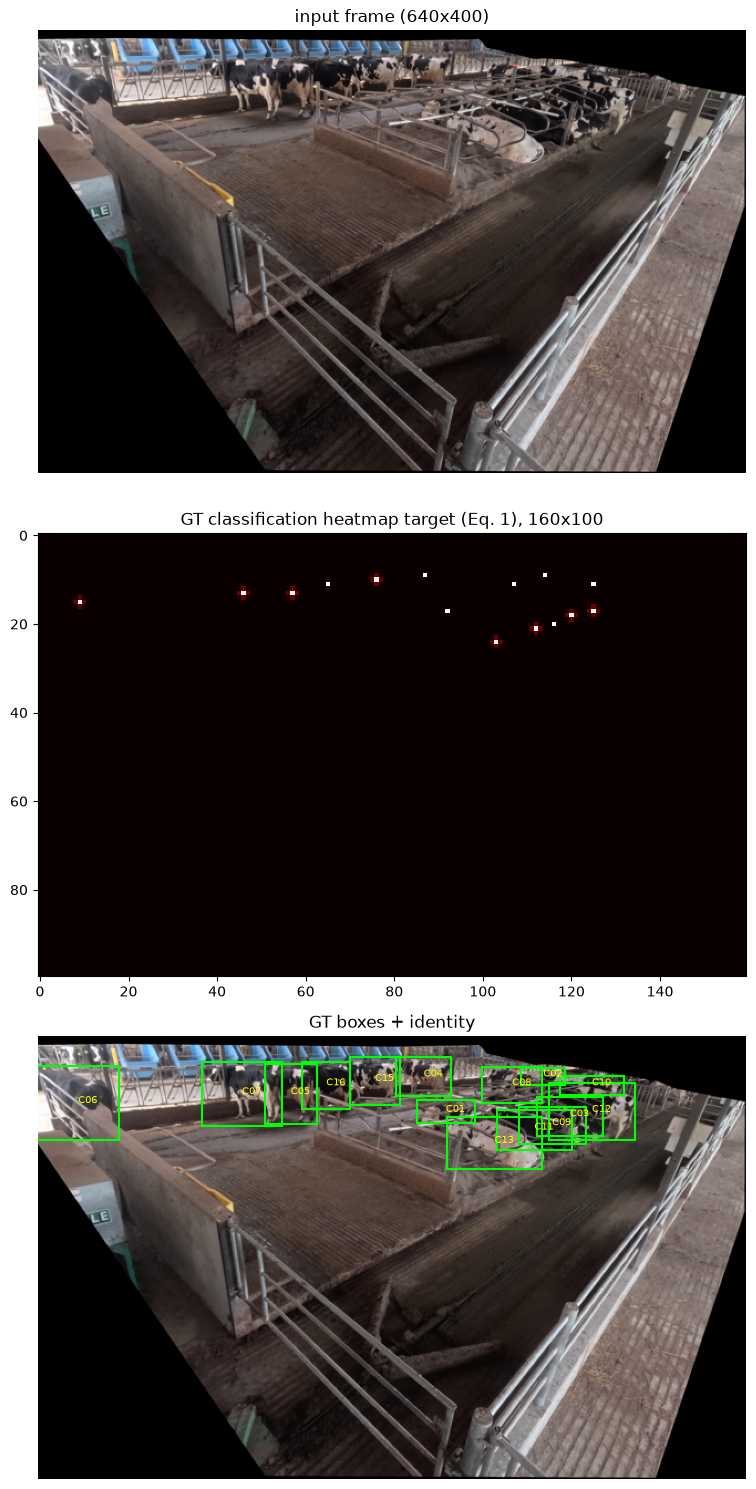

In [4]:
import matplotlib.pyplot as plt


def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


fig, axes = plt.subplots(3, 1, figsize=(8,15))
axes[0].imshow(unnormalize(x0[0])); axes[0].set_title("input frame (640x400)"); axes[0].axis("off")
axes[1].imshow(hm0[0], cmap="hot"); axes[1].set_title("GT classification heatmap target (Eq. 1), 160x100")
axes[2].imshow(unnormalize(x0[0]))
for i in range(mask0[0].sum()):
    fx, fy = ctr0[0, i].tolist()
    w, h = sz0[0, i].tolist()
    px, py = fx * STRIDE, fy * STRIDE
    rect = plt.Rectangle((px - w * STRIDE / 2, py - h * STRIDE / 2), w * STRIDE, h * STRIDE,
                          fill=False, edgecolor="lime", linewidth=1.5)
    axes[2].add_patch(rect)
    axes[2].text(px, py, f"C{id0[0, i].item() + 1:02d}", color="yellow", fontsize=7)
axes[2].set_title("GT boxes + identity"); axes[2].axis("off")
plt.tight_layout(); plt.show()


```mermaid
flowchart LR
    A[Data frame] --> B[Parse labels]
    B --> C[Build heatmap]
    B --> D[Build offset and size targets]
    B --> E[Build identity targets]
    C --> F[Batch collate]
    D --> F
    E --> F
    F --> G[Model input]
```


In [5]:
def count_params(model):
    """Running tally for the series: n2 AlexNet=61M, n3 VGG16=138M, n4 ResNet-18=11M,
    n8 OSNet=2.2M. This network is a small custom encoder-decoder, not a paper baseline with a
    published parameter count to match -- so there is no target number here, just a sanity check
    that it is small enough to train in a notebook."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def show_shapes(model, x=None):
    """it x is not none, make zeros tensor of h, w then take out model output, print the name and shape of each output tensor"""
    x = x if x is not None else torch.zeros(1, 3, IMG_H, IMG_W).to(DEVICE)
    out = model(x)
    for name, t in out.items():
        print(f"{name:10s} {tuple(t.shape)}")


@torch.no_grad()
def decode_detections(class_score, offset, size, k=40, score_thresh=0.3):
    """Turn the network's dense classification/offset/size maps back into a list of boxes,
    following FairMOT Sec. 4.5.1: 3x3 max-pool NMS on the classification (heatmap) score (keep a
    pixel only if it is its own 3x3 neighborhood's maximum), take the top-k surviving peaks, then
    read off offset + size there. class_score: (H, W) sigmoid scores in [0,1], already reduced to
    a single foreground channel (N_CLASSES=1 for mmCows). offset, size: (2, H, W). Returns a list
    of (score, px, py, pw, ph, fx, fy) in *pixel* coordinates (already multiplied by STRIDE)."""
    H, W = class_score.shape
    pooled = F.max_pool2d(class_score.unsqueeze(0).unsqueeze(0), 3, stride=1, padding=1)[0, 0]
    peaks = (pooled == class_score) & (class_score > score_thresh)
    ys, xs = torch.where(peaks)
    scores = class_score[ys, xs]
    if len(scores) == 0:
        return []
    topk = torch.topk(scores, min(k, len(scores))).indices
    results = []
    for i in topk:
        fx, fy = xs[i].item(), ys[i].item()
        ox, oy = offset[0, fy, fx].item(), offset[1, fy, fx].item()
        w, h = size[0, fy, fx].item(), size[1, fy, fx].item()
        px, py = (fx + ox) * STRIDE, (fy + oy) * STRIDE
        results.append((scores[i].item(), px, py, w * STRIDE, h * STRIDE, fx, fy))
    return results


def box_iou(box_a, box_b):
    """IoU of two (cx, cy, w, h) boxes in the same units. Used only for evaluation, not training
    (FairMOT/CenterNet never regress IoU directly -- detection is trained via the classification
    heatmap + L1 losses below)."""
    ax1, ay1, ax2, ay2 = box_a[0] - box_a[2] / 2, box_a[1] - box_a[3] / 2, box_a[0] + box_a[2] / 2, box_a[1] + box_a[3] / 2
    bx1, by1, bx2, by2 = box_b[0] - box_b[2] / 2, box_b[1] - box_b[3] / 2, box_b[0] + box_b[2] / 2, box_b[1] + box_b[3] / 2
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    return inter / (area_a + area_b - inter + 1e-9)


```mermaid
flowchart TD
    A[Input image] --> B[Shared encoder decoder\nfeature map at stride 4]
    B --> C[Classification head\nforeground score]
    B --> D[Detection head\noffset and box size]
    B --> E[Re identification head\nembedding map]
    C --> F[Center peaks]
    D --> G[Decoded boxes]
    E --> H[Identity logits]
    F --> G
    F --> H
```

```mermaid
flowchart LR
    A[Paper DLA 34 plus deformable conv] -. simplified .-> B[Small ResNet style encoder plus plain conv fusion]
    B --> C[Notebook friendly]
    B --> D[Accuracy gap is not a bug by itself]
```


In [6]:
class ConvBNReLU(nn.Module):
    """conv -> BN -> ReLU. The one repeated building block of both the encoder and decoder."""

    def __init__(self, in_ch, out_ch, k=3, stride=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, k, stride=stride, padding=k // 2, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        return F.relu(self.bn(self.conv(x)), inplace=True)


class ResBlock(nn.Module):
    """Standard pre-ResNet residual block (He et al. 2016), used to build the downsampling
    stages. Nothing FairMOT-specific here -- any competent backbone stage works; DLA-34 itself is
    built from very similar residual/aggregation blocks."""

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = ConvBNReLU(in_ch, out_ch, stride=stride)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.shortcut = None
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False), nn.BatchNorm2d(out_ch))

    def forward(self, x):
        identity = x if self.shortcut is None else self.shortcut(x)
        out = self.conv1(x)
        out = self.bn2(self.conv2(out))
        return F.relu(out + identity, inplace=True)


class FuseUp(nn.Module):
    """One decoder step of the IDA-Up-style path: upsample the deeper (lower-resolution, more
    semantic) feature map to match the shallower one, concatenate, then fuse with a conv.
    SIMPLIFICATION vs paper: FairMOT's up-sampling convolutions are deformable; these are plain
    3x3 convs (see the architecture-overview markdown cell above for why)."""

    def __init__(self, deep_ch, shallow_ch, out_ch):
        super().__init__()
        self.reduce = ConvBNReLU(deep_ch, out_ch, k=1)
        self.fuse = ConvBNReLU(out_ch + shallow_ch, out_ch, k=3)

    def forward(self, deep, shallow):
        deep = self.reduce(deep)
        deep = F.interpolate(deep, size=shallow.shape[-2:], mode="bilinear", align_corners=False)
        return self.fuse(torch.cat([deep, shallow], dim=1))


class JointBackbone(nn.Module):
    """Encoder (stride 4/8/16/32) + decoder fusing back down to stride 4. Output: a single
    (B, C, H/4, W/4) feature map shared by every head, exactly as in FairMOT Fig. 1."""

    def __init__(self, base_ch=32):
        super().__init__()
        c1, c2, c3, c4 = base_ch, base_ch * 2, base_ch * 4, base_ch * 8
        # Stem: two stride-2 convs -> stride 4 directly (DLA-34 similarly reaches /4 immediately).
        self.stem = nn.Sequential(ConvBNReLU(3, c1, k=7, stride=2), ConvBNReLU(c1, c1, stride=2))
        self.stage8 = ResBlock(c1, c2, stride=2)     # /8
        self.stage16 = ResBlock(c2, c3, stride=2)    # /16
        self.stage32 = ResBlock(c3, c4, stride=2)    # /32

        self.up16 = FuseUp(c4, c3, c3)   # /32 -> fuse with /16
        self.up8 = FuseUp(c3, c2, c2)    # -> fuse with /8
        self.up4 = FuseUp(c2, c1, c1)    # -> fuse with /4 (stem output)

        self.out_channels = c1

    def forward(self, x):
        f4 = self.stem(x)
        f8 = self.stage8(f4)
        f16 = self.stage16(f8)
        f32 = self.stage32(f16)
        d16 = self.up16(f32, f16)
        d8 = self.up8(d16, f8)
        d4 = self.up4(d8, f4)
        return d4  # (B, out_channels, H/4, W/4)


def make_head(in_ch, mid_ch, out_ch):
    """Every head in FairMOT is '3x3 conv (256 ch) -> 1x1 conv -> target' (Sec. 4.2.2/4.3). We
    keep the same two-layer shape, just with a smaller mid channel count to match the smaller
    backbone."""
    return nn.Sequential(
        nn.Conv2d(in_ch, mid_ch, 3, padding=1), nn.ReLU(inplace=True),
        nn.Conv2d(mid_ch, out_ch, 1))


class JointDetReIDModel(nn.Module):
    """Three named heads on one shared backbone, per the user's requirement:

      classification (N_CLASSES, H/4, W/4)  foreground/objectness score, Eq. 1
                                              (N_CLASSES=1 for mmCows: cow vs. background)
      detection: offset (2, H/4, W/4)        sub-pixel center correction, Eq. 2
      detection: size   (2, H/4, W/4)        box width/height in feature units, Eq. 2
      reid      (128, H/4, W/4)              identity embedding map, Sec. 4.3 (dim=128, the
                                              paper's own choice after their Sec. 5.3.4 ablation --
                                              Table 6 shows LOW-dimensional re-ID features are
                                              better for the joint task, not worse)

    The re-ID head outputs an embedding *map* rather than direct class scores, matching the
    paper's design: the actual identity classification happens by gathering the embedding at the
    object's center and passing it through one shared FC+softmax (identity_fc below), not a
    per-pixel classifier. This is what lets the embedding double as a tracking feature at
    inference time (Sec. 4.5.2) while still being trained with a plain classification loss."""

    def __init__(self, n_classes=N_CLASSES, n_identities=N_IDENTITIES, reid_dim=128):
        super().__init__()
        self.backbone = JointBackbone(base_ch=32)
        c = self.backbone.out_channels
        self.classification_head = make_head(c, 64, n_classes)
        self.offset_head = make_head(c, 64, 2)
        self.size_head = make_head(c, 64, 2)
        self.reid_head = make_head(c, 64, reid_dim)

        # Sec. 4.3.1: "extract the re-ID feature vector ... use a fully connected layer and a
        # softmax to map it to a class distribution".
        self.identity_fc = nn.Linear(reid_dim, n_identities)

        # Eq. 4/5: one learnable log-uncertainty per task. The paper groups heatmap+box under one
        # "detection" weight and gives re-ID its own (2 terms total, Eq. 5). Since the user wants
        # 3 *named* heads rather than 2, this notebook unbundles that into 3 separate learnable
        # weights (classification, detection, re-ID) -- see the loss section for the exact
        # formula and why this is flagged as a reorganization of Eq. 5, not a literal copy of it.
        self.log_vars = nn.Parameter(torch.zeros(3))

    def forward(self, x):
        feat = self.backbone(x)
        return {
            "classification": torch.sigmoid(self.classification_head(feat)),
            "offset": self.offset_head(feat),
            "size": self.size_head(feat),
            "reid_map": self.reid_head(feat),
        }

    def gather_embeddings(self, feat_map, centers, mask):
        """Pick out the embedding vector at each GT center. feat_map: (B, C, H, W).
        centers: (B, N, 2) feature-map (x, y) ints. mask: (B, N) bool, which slots are real boxes.
        Returns (n_valid, C) embeddings, matched 1:1 with the flattened valid rows of centers."""
        B, C, H, W = feat_map.shape
        flat = feat_map.permute(0, 2, 3, 1).reshape(B, H * W, C)  # (B, H*W, C)
        idx = (centers[..., 1] * W + centers[..., 0]).clamp(0, H * W - 1)  # (B, N) -> flat index
        gathered = torch.gather(flat, 1, idx.unsqueeze(-1).expand(-1, -1, C))  # (B, N, C)
        return gathered[mask]


model = JointDetReIDModel().to(DEVICE)
print("trainable parameters:", f"{count_params(model):,}")
show_shapes(model)


trainable parameters: 1,736,632
classification (1, 1, 100, 160)
offset     (1, 2, 100, 160)
size       (1, 2, 100, 160)
reid_map   (1, 128, 100, 160)


```mermaid
flowchart LR
    A[Three outputs] --> B[Classification focal loss]
    A --> C[Detection offset plus size loss]
    A --> D[Re identification cross entropy]
    B --> E[Learned task weighting]
    C --> E
    D --> E
    E --> F[Joint loss]
```


In [7]:
def focal_classification_loss(pred, target, alpha=2.0, beta=4.0):
    """Eq. 1. pred: (B, N_CLASSES, H, W) already sigmoid-ed. target: (B, H, W) in [0,1] (1 at
    exact centers, decaying via the Gaussian elsewhere, 0 far from any object). With
    N_CLASSES=1 this is a plain cow-vs-background focal loss."""
    pred = pred.squeeze(1).clamp(1e-6, 1 - 1e-6)
    pos_mask = (target == 1).float()
    neg_mask = (target < 1).float()
    pos_loss = -pos_mask * (1 - pred) ** alpha * torch.log(pred)
    neg_loss = -neg_mask * (1 - target) ** beta * pred ** alpha * torch.log(1 - pred)
    n_pos = pos_mask.sum().clamp(min=1)
    return (pos_loss.sum() + neg_loss.sum()) / n_pos


def detection_l1_loss(pred_offset, pred_size, offset_gt, size_gt, centers, mask, lambda_s=0.1):
    """Eq. 2, gathered at GT centers only (paper: 'the following l1 losses for the two heads')."""
    B, _, H, W = pred_offset.shape
    flat_off = pred_offset.permute(0, 2, 3, 1).reshape(B, H * W, 2)
    flat_size = pred_size.permute(0, 2, 3, 1).reshape(B, H * W, 2)
    idx = (centers[..., 1] * W + centers[..., 0]).clamp(0, H * W - 1)
    got_off = torch.gather(flat_off, 1, idx.unsqueeze(-1).expand(-1, -1, 2))[mask]
    got_size = torch.gather(flat_size, 1, idx.unsqueeze(-1).expand(-1, -1, 2))[mask]
    if got_off.numel() == 0:
        z = torch.zeros((), device=pred_offset.device)
        return z, z
    off_loss = F.l1_loss(got_off, offset_gt[mask])
    size_loss = F.l1_loss(got_size, size_gt[mask])
    return off_loss, lambda_s * size_loss


def joint_loss(model, outputs, heatmap_gt, offset_gt, size_gt, centers, identity_gt, mask):
    """Returns (total_loss, dict_of_components) for logging."""
    l_classification = focal_classification_loss(outputs["classification"], heatmap_gt)
    l_off, l_size = detection_l1_loss(outputs["offset"], outputs["size"], offset_gt, size_gt, centers, mask)
    l_detection = l_off + l_size

    reid_embed = model.gather_embeddings(outputs["reid_map"], centers, mask)
    if reid_embed.numel() > 0:
        identity_logits = model.identity_fc(reid_embed)
        l_identity = F.cross_entropy(identity_logits, identity_gt[mask])
    else:
        l_identity = torch.zeros((), device=heatmap_gt.device)

    w1, w2, w3 = model.log_vars[0], model.log_vars[1], model.log_vars[2]
    total = (1.0 / 3.0) * (
        torch.exp(-w1) * l_classification + torch.exp(-w2) * l_detection + torch.exp(-w3) * l_identity
        + w1 + w2 + w3
    )
    parts = {
        "classification": l_classification.item(), "off": l_off.item(), "size": l_size.item(),
        "identity": l_identity.item(), "total": total.item(),
        "w1": w1.item(), "w2": w2.item(), "w3": w3.item(),
    }
    return total, parts


```mermaid
flowchart TD
    A[Training setup] --> B[Adam learning rate 1e-4]
    B --> C[Forward pass]
    C --> D[Joint loss]
    D --> E[Backpropagation]
    E --> F[Update model and task weights]
    F --> G[Validation metrics]
    G --> H[History CSV]
```


In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # paper's own optimizer + starting LR (Sec. 5.2)

x, hm, off, sz, ctr, ids, mask = next(iter(train_loader))
x, hm = x.to(DEVICE), hm.to(DEVICE)
off, sz, ctr = off.to(DEVICE), sz.to(DEVICE), ctr.to(DEVICE)
ids, mask = ids.to(DEVICE), mask.to(DEVICE)

model.train()
outputs = model(x)
loss, parts = joint_loss(model, outputs, hm, off, sz, ctr, ids, mask)
print("loss components before any training:", parts)

optimizer.zero_grad()
loss.backward()
optimizer.step()
print("\nsingle step ran cleanly -- gradients flowed through all 3 heads and log_vars.")


loss components before any training: {'classification': 203.5508270263672, 'off': 0.41849854588508606, 'size': 1.4017956256866455, 'identity': 2.7531540393829346, 'total': 69.37476348876953, 'w1': 0.0, 'w2': 0.0, 'w3': 0.0}

single step ran cleanly -- gradients flowed through all 3 heads and log_vars.


```mermaid
flowchart LR
    A[Epoch] --> B[Train loss]
    B --> C[Classification loss]
    B --> D[Detection loss]
    B --> E[Re identification loss]
    A --> F[Train accuracy]
    A --> G[Validation accuracy]
    A --> H[Learning rate]
```


In [9]:
def fit(model, train_loader, val_loader, epochs=25, lr=1e-4, lr_drop_epoch=15):
    """Train the model and return one clearly labelled metrics record per epoch."""
    import time

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    log_path = Path("runs") / "n10_joint_det_reid" / "history.csv"
    log_path.parent.mkdir(parents=True, exist_ok=True)
    if log_path.exists():
        log_path.unlink()

    history = []
    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()
        if DEVICE.type == "cuda":
            torch.cuda.reset_peak_memory_stats(DEVICE)
        if epoch == lr_drop_epoch:
            for group in optimizer.param_groups:
                group["lr"] *= 0.1

        model.train()
        running = {"classification": 0.0, "off": 0.0, "size": 0.0, "identity": 0.0, "total": 0.0}
        train_correct_id, train_total_id, n_batches = 0, 0, 0
        for x, hm, off, sz, ctr, ids, mask in train_loader:
            x, hm = x.to(DEVICE), hm.to(DEVICE)
            off, sz, ctr = off.to(DEVICE), sz.to(DEVICE), ctr.to(DEVICE)
            ids, mask = ids.to(DEVICE), mask.to(DEVICE)

            outputs = model(x)
            loss, parts = joint_loss(model, outputs, hm, off, sz, ctr, ids, mask)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            for key in running:
                running[key] += parts[key]
            with torch.no_grad():
                embeddings = model.gather_embeddings(outputs["reid_map"], ctr, mask)
                if embeddings.numel():
                    predicted_ids = model.identity_fc(embeddings).argmax(1)
                    train_correct_id += (predicted_ids == ids[mask]).sum().item()
                    train_total_id += mask.sum().item()
            n_batches += 1

        for key in running:
            running[key] /= max(n_batches, 1)

        val_identity_acc = evaluate_identity_head(model, val_loader)
        epoch_seconds = time.perf_counter() - epoch_start
        gpu_mem_mb = torch.cuda.max_memory_allocated(DEVICE) / 1e6 if DEVICE.type == "cuda" else 0.0
        rec = {
            "epoch": epoch,
            "total": running["total"],
            "classification": running["classification"],
            "detection": running["off"] + running["size"],
            "off": running["off"],
            "size": running["size"],
            "identity": running["identity"],
            "train_identity_acc": 100 * train_correct_id / max(train_total_id, 1),
            "val_identity_acc": val_identity_acc,
            "epoch_seconds": epoch_seconds,
            "lr": optimizer.param_groups[0]["lr"],
            "gpu_mem_mb": gpu_mem_mb,
        }
        history.append(rec)
        with open(log_path, "a", newline="") as history_file:
            writer = csv.DictWriter(history_file, fieldnames=list(rec.keys()))
            if history_file.tell() == 0:
                writer.writeheader()
            writer.writerow(rec)

        gpu_mem_text = f"{rec['gpu_mem_mb']:>7.0f}MB" if DEVICE.type == "cuda" else "   no GPU"
        print(
            f"epoch {epoch:>3}/{epochs:<3} | "
            f"total {rec['total']:>8.3f} | cls {rec['classification']:>8.3f} | "
            f"det {rec['detection']:>8.3f} | re-id {rec['identity']:>8.3f} | "
            f"train_acc {rec['train_identity_acc']:>6.1f}% | val_acc {rec['val_identity_acc']:>6.1f}% | "
            f"time {rec['epoch_seconds']:>7.1f}s | lr {rec['lr']:.1e} | gpu {gpu_mem_text}"
        )
    return history


@torch.no_grad()
def evaluate_identity_head(model, loader):
    """Closed-set accuracy of the re-ID head at GT centers.
    FLAGGED DEVIATION from the paper: FairMOT evaluates re-ID with OPEN-set retrieval (TPR@FAR,
    IDF1 -- see n8's notebook for that style of evaluation) because MOT test identities are not
    seen in training. mmCows' 16 cows are a fixed, closed herd -- every cow in val was also seen
    (with different images) in train -- so plain classification accuracy is the meaningful, honest
    metric here, not a retrieval metric that would be testing something we didn't set up for."""
    model.eval()
    correct_id, total = 0, 0
    for x, hm, off, sz, ctr, ids, mask in loader:
        x, ctr, ids, mask = x.to(DEVICE), ctr.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)
        outputs = model(x)
        reid_embed = model.gather_embeddings(outputs["reid_map"], ctr, mask)
        if reid_embed.numel() == 0:
            continue
        id_pred = model.identity_fc(reid_embed).argmax(1)
        correct_id += (id_pred == ids[mask]).sum().item()
        total += mask.sum().item()
    if total == 0:
        return 0.0
    return 100 * correct_id / total

In [ ]:
model = JointDetReIDModel().to(DEVICE)   # fresh model
history = fit(model, train_loader, val_loader, epochs=5, lr=1e-4)


epoch   1/5   | total   34.453 | cls   99.064 | det    1.666 | re-id    2.758 | train_acc    9.6% | val_acc   11.7% | time    63.0s | lr 1.0e-04 | gpu    4735MB
epoch   2/5   | total    4.717 | cls   10.062 | det    1.431 | re-id    2.707 | train_acc   12.8% | val_acc   12.6% | time    64.8s | lr 1.0e-04 | gpu     928MB
epoch   3/5   | total    2.754 | cls    4.415 | det    1.222 | re-id    2.664 | train_acc   13.1% | val_acc   13.1% | time    54.6s | lr 1.0e-04 | gpu     930MB


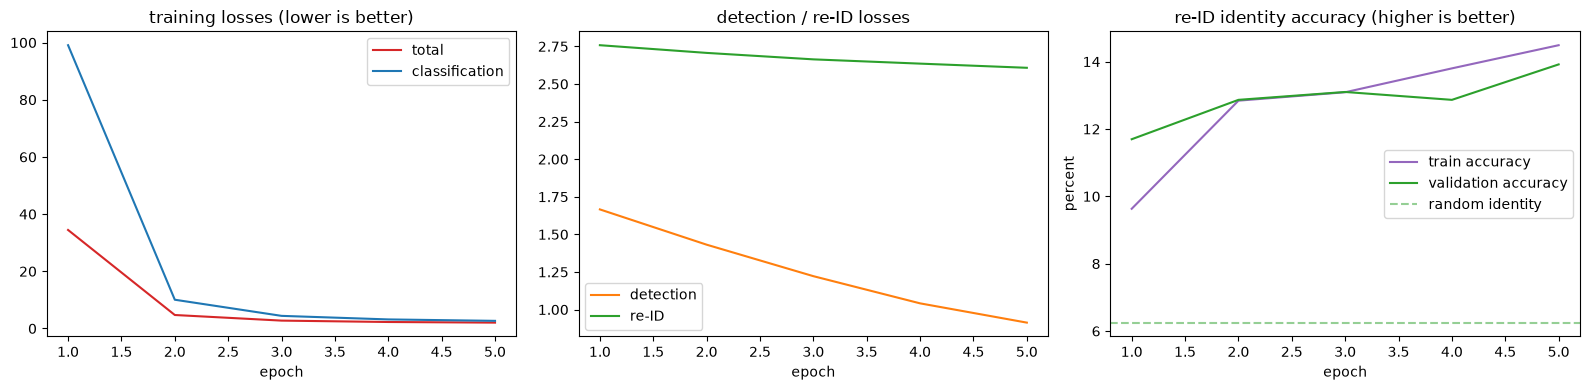


Final learned task weights (log_vars, Eq. 5 reorganized into 3 terms): [0.004695234354585409, 0.011131738312542439, 0.026101449504494667]
A more negative w_i means that task's loss is trusted/weighted more heavily.
A large positive w_i means the network has learned to downweight a noisy or hard task.


In [ ]:
def plot_history(history):
    epochs = [record["epoch"] for record in history]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(epochs, [record["total"] for record in history], label="total", color="C3")
    axes[0].plot(epochs, [record["classification"] for record in history], label="classification", color="C0")
    axes[0].set_title("training losses (lower is better)"); axes[0].legend(); axes[0].set_xlabel("epoch")
    axes[1].plot(epochs, [record["detection"] for record in history], label="detection", color="C1")
    axes[1].plot(epochs, [record["identity"] for record in history], label="re-ID", color="C2")
    axes[1].set_title("detection / re-ID losses"); axes[1].legend(); axes[1].set_xlabel("epoch")
    axes[2].plot(epochs, [record["train_identity_acc"] for record in history], label="train accuracy", color="C4")
    axes[2].plot(epochs, [record["val_identity_acc"] for record in history], label="validation accuracy", color="C2")
    axes[2].axhline(100 / N_IDENTITIES, ls="--", color="C2", alpha=0.5, label="random identity")
    axes[2].set_title("re-ID identity accuracy (higher is better)")
    axes[2].legend(); axes[2].set_xlabel("epoch"); axes[2].set_ylabel("percent")
    plt.tight_layout(); plt.show()


plot_history(history)
print("\nFinal learned task weights (log_vars, Eq. 5 reorganized into 3 terms):",
      model.log_vars.detach().cpu().tolist())
print("A more negative w_i means that task's loss is trusted/weighted more heavily.")
print("A large positive w_i means the network has learned to downweight a noisy or hard task.")

```mermaid
flowchart TD
    A[Validation frames] --> B[Decode center peaks]
    B --> C[Classification plus detection]
    C --> D[IoU matching]
    D --> E[Precision and recall]
    A --> F[Re identification at GT centers]
    F --> G[Closed set identity accuracy]
```


In [ ]:
@torch.no_grad()
def evaluate_detection(model, loader, iou_thresh=0.5, score_thresh=0.3):
    model.eval()
    tp, fp, fn = 0, 0, 0
    for x, hm, off, sz, ctr, ids, mask in loader:
        x = x.to(DEVICE)
        outputs = model(x)
        for b in range(x.shape[0]):
            dets = decode_detections(outputs["classification"][b, 0], outputs["offset"][b],
                                      outputs["size"][b], score_thresh=score_thresh)
            gt_boxes = []
            for i in range(mask.shape[1]):
                if not mask[b, i]:
                    continue
                fx, fy = ctr[b, i].tolist()
                w, h = sz[b, i].tolist()
                gt_boxes.append((fx * STRIDE, fy * STRIDE, w * STRIDE, h * STRIDE))
            matched_gt = set()
            for score, px, py, w, h, fx, fy in dets:
                best_iou, best_j = 0.0, -1
                for j, gb in enumerate(gt_boxes):
                    if j in matched_gt:
                        continue
                    iou = box_iou((px, py, w, h), gb)
                    if iou > best_iou:
                        best_iou, best_j = iou, j
                if best_iou >= iou_thresh:
                    tp += 1
                    matched_gt.add(best_j)
                else:
                    fp += 1
            fn += len(gt_boxes) - len(matched_gt)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    return precision, recall, tp, fp, fn


precision, recall, tp, fp, fn = evaluate_detection(model, val_loader)
id_acc = evaluate_identity_head(model, val_loader)
print(f"Classification+Detection (IoU>=0.5): precision={precision:.2%}  recall={recall:.2%}  (tp={tp}, fp={fp}, fn={fn})")
print(f"Identity accuracy (closed-set, 16 known cows): {id_acc:.1f}%  (random guess: {100/N_IDENTITIES:.1f}%)")


Classification+Detection (IoU>=0.5): precision=0.00%  recall=0.00%  (tp=0, fp=0, fn=855)
Identity accuracy (closed-set, 16 known cows): 13.9%  (random guess: 6.2%)


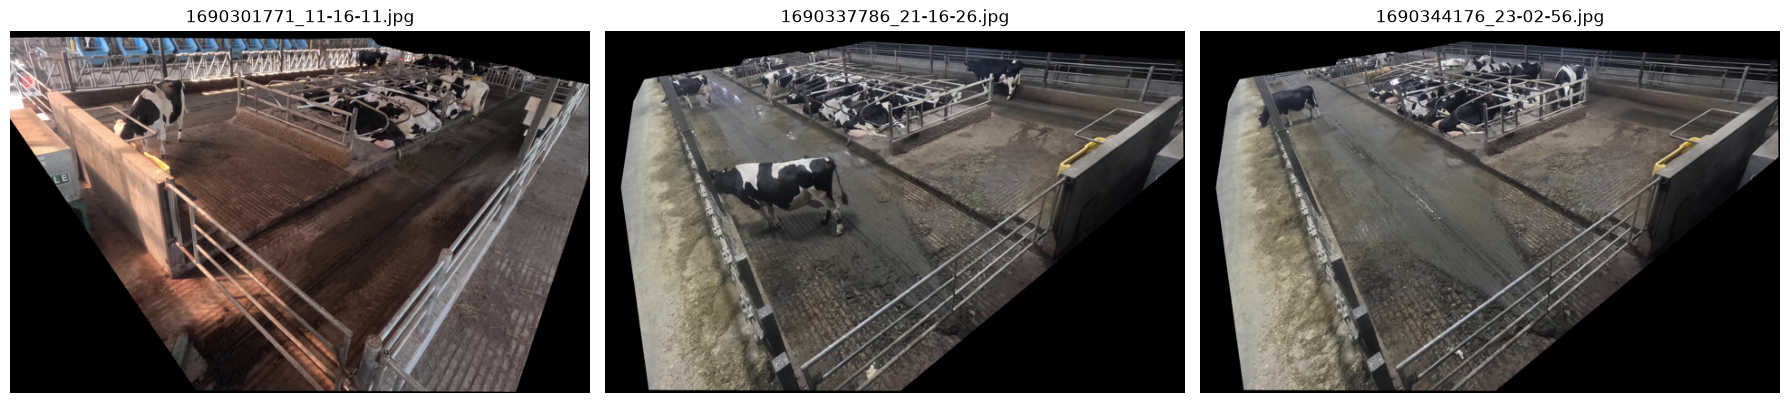

In [ ]:
# Qualitative check: decoded detections + predicted identity on val frames.
@torch.no_grad()
def predict_and_draw(model, dataset_samples, n_show=3):
    model.eval()
    fig, axes = plt.subplots(1, n_show, figsize=(6 * n_show, 6))
    if n_show == 1:
        axes = [axes]
    for a, (img_path, boxes) in zip(axes, dataset_samples[:n_show]):
        img = Image.open(img_path).convert("RGB").resize((IMG_W, IMG_H))
        import numpy as np
        arr = np.array(img).astype("float32") / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        x = (torch.from_numpy(arr).permute(2, 0, 1) - mean) / std
        outputs = model(x.unsqueeze(0).to(DEVICE))
        dets = decode_detections(outputs["classification"][0, 0], outputs["offset"][0], outputs["size"][0],
                                  score_thresh=0.3)
        a.imshow(arr)
        for score, px, py, w, h, fx, fy in dets:
            reid_vec = outputs["reid_map"][0, :, fy, fx].unsqueeze(0)
            pred_id = model.identity_fc(reid_vec).argmax(1).item() + 1
            a.add_patch(plt.Rectangle((px - w / 2, py - h / 2), w, h, fill=False, edgecolor="lime", linewidth=1.5))
            a.text(px, py - h / 2, f"C{pred_id:02d} {score:.2f}", color="yellow", fontsize=7)
        a.set_title(img_path.name); a.axis("off")
    plt.tight_layout(); plt.show()


predict_and_draw(model, VAL_SAMPLES, n_show=3)


```mermaid
flowchart TD
    A[Anchor free] --> B[Center plus size]
    C[Heatmap] --> D[Foreground confidence]
    E[Gaussian radius] --> F[Stable center target]
    G[Uncertainty weighting] --> H[Learned task balance]
    I[Closed set re identification] --> J[Known cow classifier]
    K[Feature fusion] --> L[Fine spatial plus deep semantic features]
```


```mermaid
flowchart TD
    A[Baseline run] --> B[Change one setting]
    B --> C[Train again]
    C --> D[Compare losses and metrics]
    D --> E[Keep or revert the change]
    B --> F[Uncertainty weighting]
    B --> G[Geometric augmentation]
    B --> H[Deformable convolution]
    B --> I[Embedding dimension]
    B --> J[Online association]
    B --> K[Held out camera]
```


```mermaid
flowchart LR
    A[Trained model] --> B[Atomic checkpoint write]
    B --> C[model.pt]
    A --> D[History]
    D --> E[history.csv]
    A --> F[Configuration]
    F --> G[config.json inside checkpoint]
```


In [ ]:
RUN_DIR = Path("runs") / "n10_joint_det_reid"
RUN_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = RUN_DIR / "model.pt"
TEMP_CHECKPOINT_PATH = RUN_DIR / "model.pt.tmp"

checkpoint = {
    "model_state": {key: value.detach().cpu() for key, value in model.state_dict().items()},
    "history": history,
    "config": {
        "dataset": DATASET_NAME, "data_root": str(DATA_ROOT), "cameras": list(CAMERAS),
        "img_w": IMG_W, "img_h": IMG_H, "stride": STRIDE,
        "n_classes": N_CLASSES, "n_identities": N_IDENTITIES,
        "frame_stride": FRAME_STRIDE,
    },
}

torch.save(checkpoint, TEMP_CHECKPOINT_PATH)
try:
    verified = torch.load(TEMP_CHECKPOINT_PATH, map_location="cpu", weights_only=False)
    if not verified.get("model_state") or not verified.get("history"):
        raise RuntimeError("checkpoint verification failed: missing model state or history")
    TEMP_CHECKPOINT_PATH.replace(CHECKPOINT_PATH)
finally:
    if TEMP_CHECKPOINT_PATH.exists():
        TEMP_CHECKPOINT_PATH.unlink()

print(f"saved and verified {DATASET_NAME} model + history to {CHECKPOINT_PATH}")


saved and verified mmCows model + history to runs\n10_joint_det_reid\model.pt
